# import


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa,librosa.display
import IPython.display as ipd
import soundfile as sf
import os



In [3]:
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [4]:
from huggingface_hub import login

login()

e:\moved_from_C\cc\pythonEnvironment\anaconda\Lib\site-packages\huggingface_hub\constants.py:298: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


     Downloaded the 28 letter classes from Hugging Face and generated alphabet dataset


In [5]:
import time
from huggingface_hub import snapshot_download

letter_classes = [
    "Alif", "Ba", "Ta", "Tha", "Jeem", "Hha", "Kha", "Dal", "zal", "Ra", "Zai",
    "Seen", "Sheen", "sad", "Dad", "Tah", "Zah", "Ayn", "Gheen", "Fa", "Qaf",
    "Kaf", "Lam", "Meem", "Noon", "Ha", "Wow", "Ya"
]

local_root = r"E:\baby_developer\abjad_letters"            
log_file = os.path.join(local_root, "download_progress.txt")


os.makedirs(local_root, exist_ok=True)

completed = set()
if os.path.exists(log_file):
    with open(log_file, "r") as f:
        completed = set(line.strip() for line in f if line.strip())

print(f"already Done  : {len(completed)} / {len(letter_classes)}\n")

MAX_RETRIES = 5
BASE_WAIT = 15  # second - delay before the next download 

failed = []
for i, letter in enumerate(letter_classes, 1):
    if letter in completed:
        print(f"[{i}/{len(letter_classes)}] {letter} - skip(already exist)")
        continue

    success = False
    for attempt in range(1, MAX_RETRIES + 1):
        print(f"[{i}/{len(letter_classes)}] {letter} (try {attempt}/{MAX_RETRIES}) ...")
        try:
            snapshot_download(
                repo_id="Aziz-snoubra/Abjad-Kids",
                repo_type="dataset",
                allow_patterns=[f"alphabet/{letter}/**"],
                local_dir=local_root
            )
            with open(log_file, "a") as f:
                f.write(letter + "\n")
            print(f" Done: {letter}")
            success = True
            break

        except Exception as e:
            error_msg = str(e)
            if "429" in error_msg:
                wait_time = BASE_WAIT * (2 ** (attempt - 1))  # exponential backoff: 15, 30, 60, 120, 240
                print(f" 429 Too Many Requests - try again after {wait_time} second...")
                time.sleep(wait_time)
            else:
                print(f"error: {error_msg}")
                time.sleep(5)

    if not success:
        failed.append(letter)
        print(f"completely failed {MAX_RETRIES} Attempts: {letter}")

    # A slight delay between each letter to avoid overloading the server
    time.sleep(BASE_WAIT)

print("\n==========")
completed_now = set()
if os.path.exists(log_file):
    with open(log_file, "r") as f:
        completed_now = set(line.strip() for line in f if line.strip())

already Done  : 28 / 28

[1/28] Alif - skip(already exist)
[2/28] Ba - skip(already exist)
[3/28] Ta - skip(already exist)
[4/28] Tha - skip(already exist)
[5/28] Jeem - skip(already exist)
[6/28] Hha - skip(already exist)
[7/28] Kha - skip(already exist)
[8/28] Dal - skip(already exist)
[9/28] zal - skip(already exist)
[10/28] Ra - skip(already exist)
[11/28] Zai - skip(already exist)
[12/28] Seen - skip(already exist)
[13/28] Sheen - skip(already exist)
[14/28] sad - skip(already exist)
[15/28] Dad - skip(already exist)
[16/28] Tah - skip(already exist)
[17/28] Zah - skip(already exist)
[18/28] Ayn - skip(already exist)
[19/28] Gheen - skip(already exist)
[20/28] Fa - skip(already exist)
[21/28] Qaf - skip(already exist)
[22/28] Kaf - skip(already exist)
[23/28] Lam - skip(already exist)
[24/28] Meem - skip(already exist)
[25/28] Noon - skip(already exist)
[26/28] Ha - skip(already exist)
[27/28] Wow - skip(already exist)
[28/28] Ya - skip(already exist)



    split file name  to : class /file name/child_id/record_id=UUID/copy_num / file hash

In [6]:
import re  #regrex ->"regular expression"
import hashlib

alphabet_path = r"E:\baby_developer\abjad_letters\alphabet"

#  standard UUID pattern (8_4_4_4_12 hex 0-9/a-f/A-F)
uuid_pattern = re.compile(
    r'[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}'
)

alphabet_data = []

for class_name in os.listdir(alphabet_path):
    class_path = os.path.join(alphabet_path, class_name)
    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        if not file_name.lower().endswith(".wav"):
            continue

        name_without_ext = os.path.splitext(file_name)[0]

        match = uuid_pattern.search(name_without_ext)
        if match:
            recording_id = match.group()  # UUID 
            before_uuid = name_without_ext[:match.start()].rstrip("_")
            after_uuid = name_without_ext[match.end():].lstrip("_")  # empty or"2"or"3"

            # child_id
            if before_uuid.startswith(class_name + "_"):
                child_id = before_uuid[len(class_name) + 1:]
            else:
                child_id = before_uuid

            copy_num = after_uuid if after_uuid else "1"
        else:
            # UUID not (unexpected)
            child_id = "UNKNOWN"
            recording_id = "UNKNOWN"
            copy_num = "UNKNOWN"

        file_path = os.path.join(class_path, file_name)

        hash_md5 = hashlib.md5()
        with open(file_path, "rb") as f:
            for chunk in iter(lambda: f.read(4096), b""):
                hash_md5.update(chunk)
        file_hash = hash_md5.hexdigest()

        alphabet_data.append({
            "class": class_name,
            "file_name": file_name,
            "child_id": child_id,
            "recording_id": recording_id,  # UUID 
            "copy_num": copy_num,          
            "file_hash": file_hash
        })
alphabet_data = pd.DataFrame(alphabet_data)
display(alphabet_data.head(5))

,class,file_name,child_id,recording_id,copy_num,file_hash
0,Alif,Alif_adam khatab_1d0e6910-bb75-4f8a-b2e9-d2e9a...,adam khatab,1d0e6910-bb75-4f8a-b2e9-d2e9a31ba537,1,17ac51a1bb867fb82d5d38200f892630
1,Alif,Alif_adam khatab_9a3177ef-5874-4697-b561-deac0...,adam khatab,9a3177ef-5874-4697-b561-deac0a2325c4,1,972a228c9bc53af0dc1a0b67d967e56c
2,Alif,Alif_adam_168f5686-b7ad-4862-90a3-2b060c73f168...,adam,168f5686-b7ad-4862-90a3-2b060c73f168,1,01cc2c628df3efd5184edcca72be5805
3,Alif,Alif_adam_5e698352-7afe-4c13-a633-ac34bb435729...,adam,5e698352-7afe-4c13-a633-ac34bb435729,1,4764f7f0e34ac2bb90ae3ff37ef2b62f
4,Alif,Alif_adam_a114e624-b2c9-4f06-a0b6-f189b359a6c5...,adam,a114e624-b2c9-4f06-a0b6-f189b359a6c5,1,a5ad6ba9e75dbe5d85ba9b7a529f5764


In [7]:
print("Total files:", len(alphabet_data)) #num of audio files
print("Total classes:", alphabet_data["class"].nunique()) #num of letters
print("Unique children:", alphabet_data["child_id"].nunique())
print("Unknown children:",
      (alphabet_data["child_id"] == "UNKNOWN").sum())

print("\nClasses and number of files:")
class_counts = (
    alphabet_data
    .groupby("class")
    .size()
    .reset_index(name="num_files")
    .sort_values("num_files", ascending=False)
)

print(class_counts.head(10).to_string(index=False))

Total files: 4676
Total classes: 28
Unique children: 237
Unknown children: 0

Classes and number of files:
class  num_files
   Ta        176
  Zai        174
  Kha        173
  Tha        172
Sheen        171
  Dal        170
  Wow        170
   Ra        170
  Hha        169
   Fa        169


    
    remove duplicated files 
    

In [8]:
num_copies = (
    alphabet_data
    .groupby(["class", "child_id", "recording_id", "file_hash"])
    .agg(
        num_copies=("file_name", "count"),
        files=("file_name", list)
    )
    .reset_index()
    #.sort_values("num_copies", ascending=False)
)
print("\nContain All Sets \"duplicated & unique\":")
display(num_copies.head(5).style.hide(axis="index"))


Contain All Sets "duplicated & unique":


class,child_id,recording_id,file_hash,num_copies,files
Alif,Amer,7231ea63-7798-4960-a68a-aca33dbf8960,5fb1d4f5c000e4aef4c3423131f62e19,1,['Alif_Amer_7231ea63-7798-4960-a68a-aca33dbf8960.wav']
Alif,Amer,737880b4-0afd-450b-929e-0eb937cfbf79,44d328d66fc33637e0f0d1a4e4d22bcb,1,['Alif_Amer_737880b4-0afd-450b-929e-0eb937cfbf79.wav']
Alif,Ayla,68258bd7-cf23-485a-95d6-a7d1eae516fd,d1f0b0e428e58ba16dae9a23b14c11b3,1,['Alif_Ayla_68258bd7-cf23-485a-95d6-a7d1eae516fd.wav']
Alif,Ayla,e7643761-1872-47c2-857b-f91bf7f9cb01,52d2ea373de1e17fbb07a195127e81f3,1,['Alif_Ayla_e7643761-1872-47c2-857b-f91bf7f9cb01.wav']
Alif,Diana,52907dbc-e69a-41dc-8e94-d4160477590c,77bb0f7a12d047f0660c435406d5264a,1,['Alif_Diana_52907dbc-e69a-41dc-8e94-d4160477590c.wav']


In [9]:
duplicated_files = num_copies[
    num_copies["num_copies"] > 1
]
print("Number of duplicated files:", len(duplicated_files))
print("Number of duplicate files to remove:", 
      duplicated_files["num_copies"].sub(1).sum())
print("\nContain Only \"Duplicated\" Sets:")

display(duplicated_files.head(5).style.hide(axis="index"))

Number of duplicated files: 0
Number of duplicate files to remove: 0

Contain Only "Duplicated" Sets:


class,child_id,recording_id,file_hash,num_copies,files


In [10]:
files_to_delete = []
files_to_keep = []

for _, row in duplicated_files.iterrows():
    files_list = sorted(row["files"])
    files_to_keep.append(files_list[0])
    files_to_delete.extend(files_list[1:])

print("Files to delete:", len(files_to_delete))
print("Files to keep (first copy of each group):", len(files_to_keep))

Files to delete: 0
Files to keep (first copy of each group): 0


In [ ]:
deleted_count = 0
missing_count = 0

for _, row in duplicated_files.iterrows():
    class_name = row["class"]
    files_list = sorted(row["files"])

    for dup_file in files_list[1:]:
        file_path = os.path.join(alphabet_path, class_name, dup_file)
        if os.path.exists(file_path):
            os.remove(file_path)
            deleted_count += 1
        else:
            missing_count += 1

print("Deleted:", deleted_count)
print("Already missing (skipped):", missing_count)



Deleted: 0
Already missing (skipped): 0


In [14]:
alphabet_data_clean = alphabet_data[~alphabet_data["file_name"].isin(files_to_delete)].reset_index(drop=True)
print("Rows in alphabet_data_clean:", len(alphabet_data_clean))

alphabet_data_clean.to_csv(r"E:\baby_developer\abjad_letters\\alphabet_data_clean.csv", index=False)
print("Saved alphabet_data_clean.csv")

Rows in alphabet_data_clean: 4676
Saved alphabet_data_clean.csv


    split dataset into "train/val/test"


In [15]:
# We split the data by child ID to ensure that recordings from the same child do not appear in both training and testing sets,
# preventing data leakage and ensuring a fair evaluation of the model's ability to generalize to unseen children.
   
from sklearn.model_selection import train_test_split

unique_children = alphabet_data_clean["child_id"].unique()

train_children, temp_children = train_test_split(unique_children, test_size=0.3, random_state=42) #70 train:30 test,val
val_children, test_children = train_test_split(temp_children, test_size=0.5, random_state=42)     #50 test: 50 val

alphabet_data_clean["split"] =alphabet_data_clean ["child_id"].apply(
    lambda c: "train" if c in train_children else ("val" if c in val_children else "test")
)

print(
    alphabet_data_clean.groupby("split")["child_id"].nunique()
    .reset_index(name="Number of children")
    .to_string(index=False)
    ,"\n"
)
print(
    alphabet_data_clean.groupby("split").size()
    .reset_index(name="Num of audio files")
    .to_string(index=False)
      )
display(alphabet_data_clean.head(5))

split  Number of children
 test                  36
train                 165
  val                  36 

split  Num of audio files
 test                 721
train                3485
  val                 470


,class,file_name,child_id,recording_id,copy_num,file_hash,split
0,Alif,Alif_adam khatab_1d0e6910-bb75-4f8a-b2e9-d2e9a...,adam khatab,1d0e6910-bb75-4f8a-b2e9-d2e9a31ba537,1,17ac51a1bb867fb82d5d38200f892630,train
1,Alif,Alif_adam khatab_9a3177ef-5874-4697-b561-deac0...,adam khatab,9a3177ef-5874-4697-b561-deac0a2325c4,1,972a228c9bc53af0dc1a0b67d967e56c,train
2,Alif,Alif_adam_168f5686-b7ad-4862-90a3-2b060c73f168...,adam,168f5686-b7ad-4862-90a3-2b060c73f168,1,01cc2c628df3efd5184edcca72be5805,train
3,Alif,Alif_adam_5e698352-7afe-4c13-a633-ac34bb435729...,adam,5e698352-7afe-4c13-a633-ac34bb435729,1,4764f7f0e34ac2bb90ae3ff37ef2b62f,train
4,Alif,Alif_adam_a114e624-b2c9-4f06-a0b6-f189b359a6c5...,adam,a114e624-b2c9-4f06-a0b6-f189b359a6c5,1,a5ad6ba9e75dbe5d85ba9b7a529f5764,train


# Audio Quality Check "silent files -Trimmed files - padding -truncation"


In [17]:
def check_audio_quality(file_path):
    try:
        # Load audio without changing original sample rate
        y, sr = librosa.load(
            file_path,
            sr=None,
            mono=False
        )

        # Duration
        duration = librosa.get_duration(
            y=y,
            sr=sr
        )

        # Number of channels
        if y.ndim == 1:
            channels = 1
            y_mono = y
        else:
            channels = y.shape[0]
            y_mono = np.mean(y, axis=0)

        # Maximum amplitude
        max_amplitude = np.max(np.abs(y_mono))

        # RMS Energy
        rms = np.sqrt(np.mean(y_mono ** 2))

        # Check if the whole audio is almost silent
        is_silent = max_amplitude < 0.01

        return {
            "sample_rate": sr,
            "duration": duration,
            "channels": channels,
            "max_amplitude": max_amplitude,
            "rms": rms,
            "is_silent": is_silent,
            "status": "OK"
        }

    except Exception as e:

        return {
            "sample_rate": None,
            "duration": None,
            "channels": None,
            "max_amplitude": None,
            "rms": None,
            "is_silent": None,
            "status": f"ERROR: {str(e)}"
        }

In [18]:
quality_results = []

total_files = len(alphabet_data_clean)

for index, row in alphabet_data_clean.iterrows():

    file_path = os.path.join(
        alphabet_path,
        row["class"],
        row["file_name"]
    )

    result = check_audio_quality(file_path)

    quality_results.append(result)

    if (index + 1) % 1000  == 0:
        print(f"Checked {index + 1} / {total_files} files")

# Create Quality Check DataFrame
quality_df = pd.DataFrame(quality_results)


print("Quality check completed on", total_files, "files")
#print("Number of files:", len(alphabet_data_clean))
#print("Number of quality results:", len(quality_df))


Checked 1000 / 4676 files
Checked 2000 / 4676 files
Checked 3000 / 4676 files
Checked 4000 / 4676 files
Quality check completed on 4676 files


In [20]:
quality_columns = quality_df.columns.tolist()

# Find missing quality columns
missing_quality_cols = [
    col for col in quality_columns
    if col not in alphabet_data_clean.columns
]

# Add only missing columns
if missing_quality_cols:
    alphabet_data_clean = pd.concat(
        [
            alphabet_data_clean.reset_index(drop=True),
            quality_df[missing_quality_cols].reset_index(drop=True)
        ],
        axis=1
    )
    print("Missing quality columns added successfully.")
else:
    print("All quality columns already exist. No merge needed.")

# Final checks
duplicated_columns = alphabet_data_clean.columns[
    alphabet_data_clean.columns.duplicated()
].tolist()

print("\nDuplicated columns:", duplicated_columns)
print("Total rows:", len(alphabet_data_clean))

All quality columns already exist. No merge needed.

Duplicated columns: []
Total rows: 4676


In [21]:

print("Total rows after merge:", len(alphabet_data_clean))
print("\nStatus breakdown:\n")
print(alphabet_data_clean["status"].value_counts()
      .reset_index(name="count")    
      .to_string(index=False))

print("\nSilent files found:", alphabet_data_clean["is_silent"].sum())
print("Errors found:", (alphabet_data_clean["status"] != "OK").sum())

print("\nSample rate distribution:\n")
print(alphabet_data_clean["sample_rate"].value_counts()
      .reset_index(name="count")
      .to_string(index=False))

print("\nDuration stats:\n")
print(alphabet_data_clean["duration"].describe())

print("\nChannel distribution:\n")
print(alphabet_data_clean["channels"].value_counts()
      .reset_index(name="count")
      .to_string(index=False))

Total rows after merge: 4676

Status breakdown:

status  count
    OK   4676

Silent files found: 0
Errors found: 0

Sample rate distribution:

 sample_rate  count
       16000   4676

Duration stats:

count    4676.0
mean        2.0
std         0.0
min         2.0
25%         2.0
50%         2.0
75%         2.0
max         2.0
Name: duration, dtype: float64

Channel distribution:

 channels  count
        1   4676


        check silence

In [22]:
silent_files = alphabet_data_clean[alphabet_data_clean["is_silent"] == True]

print("Silent files distribution by class:")
print(silent_files.groupby("class").size().sort_values(ascending=False).reset_index(name="count").to_string(index=False))



Silent files distribution by class:
Empty DataFrame
Columns: [class, count]
Index: []


In [23]:
print("\nSilent files distribution by split:")
print(silent_files.groupby("split").size().reset_index(name="count").to_string(index=False))
display(silent_files[["class", "file_name", "max_amplitude", "rms", "split"]].head(5).style.hide(axis="index"))


Silent files distribution by split:
Empty DataFrame
Columns: [split, count]
Index: []


class,file_name,max_amplitude,rms,split


    
    Compares n_samples silent files against a normal file from the same class,
    showing waveform + playback + stats for each pair.


In [24]:
from IPython.display import Audio, display

def inspect_silent_vs_normal(alphabet_data_clean, alphabet_path, n_samples=5, random_state=42):

    silent_files = alphabet_data_clean[alphabet_data_clean["is_silent"] == True]

    if len(silent_files) == 0:
        print("No silent files found.")
        return

    # Sample across different classes when possible, not just the first N rows
    sample = silent_files.sample(n=min(n_samples, len(silent_files)), random_state=random_state)

    for _, silent_row in sample.iterrows():
        class_name = silent_row["class"]

        normal_candidates = alphabet_data_clean[
            (alphabet_data_clean["class"] == class_name) &
            (alphabet_data_clean["is_silent"] == False)
        ]

        if len(normal_candidates) == 0:
            print(f"No normal reference found for class '{class_name}' - skipping comparison")
            continue

        normal_row = normal_candidates.iloc[0]

        silent_path = os.path.join(alphabet_path, class_name, silent_row["file_name"])
        normal_path = os.path.join(alphabet_path, class_name, normal_row["file_name"])

        silent_wave, sr_s = librosa.load(silent_path, sr=None, mono=True)
        normal_wave, sr_n = librosa.load(normal_path, sr=None, mono=True)

        print(f"\n{'='*60}")
        print(f"CLASS: {class_name}")
        print(f"{'='*60}")

        fig, axes = plt.subplots(1, 2, figsize=(14, 3))

        axes[0].plot(silent_wave)
        axes[0].set_title(f"Silent Sample - {silent_row['child_id']}\nmax_amp={silent_row['max_amplitude']:.4f}")
        axes[0].set_xlabel("Sample")
        axes[0].set_ylabel("Amplitude")

        axes[1].plot(normal_wave)
        axes[1].set_title(f"Normal Sample- {normal_row['child_id']}\nmax_amp={normal_row['max_amplitude']:.4f}")
        axes[1].set_xlabel("Sample")

        plt.tight_layout()
        plt.show()

        print("Silent file  ->", "child:", silent_row["child_id"], "| rms:", round(silent_row["rms"], 5))
        display(Audio(silent_wave, rate=sr_s))

        print("Normal file  ->", "child:", normal_row["child_id"], "| rms:", round(normal_row["rms"], 5))
        display(Audio(normal_wave, rate=sr_n))


# Run the inspection on 5 random silent samples across different classes
inspect_silent_vs_normal(alphabet_data_clean, alphabet_path, n_samples=3)

No silent files found.


In [25]:
def remove_silent_files(df, alphabet_path):
    silent_mask = df["is_silent"]== True
    silent_files = df[silent_mask]

    deleted_count = 0
    missing_count = 0
    error_count = 0

    for _, row in silent_files.iterrows():
        file_path = os.path.join(
            alphabet_path,
            row["class"],
            row["file_name"]
        )

        try:
            if os.path.exists(file_path):
                os.remove(file_path)
                deleted_count += 1
            else:
                missing_count += 1

        except OSError as e:
            error_count += 1
            print(f"Error deleting {file_path}: {e}")

    df_clean = df[~silent_mask].reset_index(drop=True)

    print("========== SILENT FILES REMOVAL ==========")
    print("Silent files found:", len(silent_files))
    print("Deleted:", deleted_count)
    print("Already missing:", missing_count)
    print("Deletion errors:", error_count)
    print("Total files after cleaning:", len(df_clean))
    print("Remaining silent files:", df_clean["is_silent"].sum())

    return df_clean


alphabet_data_clean = remove_silent_files(
    alphabet_data_clean,
    alphabet_path
)

========== SILENT FILES REMOVAL ==========
Silent files found: 0
Deleted: 0
Already missing: 0
Deletion errors: 0
Total files after cleaning: 4676
Remaining silent files: 0



     Analyze leading and trailing silence in an audio file.


In [26]:
from pathlib import Path


def analyze_silence(
    file_path,
    silence_threshold_db=30,
    min_silence_duration=0.1
):
    try:
        y, sr = librosa.load(
            file_path,
            sr=None,
            mono=True
        )

        duration = len(y) / sr

        # Detect non-silent intervals
        intervals = librosa.effects.split(
            y,
            top_db=silence_threshold_db
        )

        # Entire file is silent
        if len(intervals) == 0:
            return {
                "leading_silence_sec": duration,
                "trailing_silence_sec": duration,
                "speech_duration_sec": 0,
                "has_leading_silence": True,
                "has_trailing_silence": True,
                "status": "SILENT"
            }

        # First speech sample
        first_sound_start = intervals[0][0]

        # Last speech sample
        last_sound_end = intervals[-1][1]

        # Calculate durations
        leading_silence = first_sound_start / sr
        trailing_silence = (
            len(y) - last_sound_end
        ) / sr

        speech_duration = (
            last_sound_end - first_sound_start
        ) / sr

        return {
            "leading_silence_sec": leading_silence,
            "trailing_silence_sec": trailing_silence,
            "speech_duration_sec": speech_duration,

            "has_leading_silence": (
                leading_silence >= min_silence_duration
            ),

            "has_trailing_silence": (
                trailing_silence >= min_silence_duration
            ),

            "status": "OK"
        }

    except Exception as e:

        print(
            f"Error reading {file_path}: {e}"
        )

        return {
            "leading_silence_sec": np.nan,
            "trailing_silence_sec": np.nan,
            "speech_duration_sec": np.nan,
            "has_leading_silence": False,
            "has_trailing_silence": False,
            "status": "ERROR"
        }


In [27]:
silence_results = []

total_files = len(alphabet_data_clean)

for i, (_, row) in enumerate(
    alphabet_data_clean.iterrows(),
    start=1
):

    file_path = (
        Path(alphabet_path)
        / row["class"]
        / row["file_name"]
    )

    if not file_path.exists():
        continue

    result = analyze_silence(
        file_path,
        silence_threshold_db=30,
        min_silence_duration=0.1
    )

    result["class"] = row["class"]
    result["file_name"] = row["file_name"]

    silence_results.append(result)

    if i % 1000 == 0:
        print(
            f"Checked {i} / {total_files} files"
        )
print("Quality check completed on", total_files, "files")

Checked 1000 / 4676 files
Checked 2000 / 4676 files
Checked 3000 / 4676 files
Checked 4000 / 4676 files
Quality check completed on 4676 files


In [28]:
# Create DataFrame
silence_df = pd.DataFrame(silence_results)

print("\n========== SILENCE ANALYSIS ==========")

print(
    "Files analyzed:",
    len(silence_df)
)

print(
    "Leading silence:",
    silence_df["has_leading_silence"].sum()
)

print(
    "Trailing silence:",
    silence_df["has_trailing_silence"].sum()
)

print(
    "Errors:",
    (silence_df["status"] == "ERROR").sum()
)


========== SILENCE ANALYSIS ==========
Files analyzed: 4676
Leading silence: 3251
Trailing silence: 2675
Errors: 0


In [29]:
print("\nLeading Silence Statistics:")
print(
    silence_df["leading_silence_sec"].describe()
)

print("\nTrailing Silence Statistics:")
print(
    silence_df["trailing_silence_sec"].describe()
)

print("\nSpeech Duration Statistics:")
print(
    silence_df["speech_duration_sec"].describe()
)


Leading Silence Statistics:
count    4676.000000
mean        0.399986
std         0.321715
min         0.000000
25%         0.000000
50%         0.448000
75%         0.576000
max         1.728000
Name: leading_silence_sec, dtype: float64

Trailing Silence Statistics:
count    4676.000000
mean        0.422512
std         0.436134
min         0.000000
25%         0.000000
50%         0.304000
75%         0.816000
max         1.648000
Name: trailing_silence_sec, dtype: float64

Speech Duration Statistics:
count    4676.000000
mean        1.177502
std         0.632563
min         0.224000
25%         0.576000
50%         1.024000
75%         2.000000
max         2.000000
Name: speech_duration_sec, dtype: float64


In [30]:
original_path = Path(alphabet_path)
trimmed_path = original_path.parent / "abjad_letters_trimmed"
trimmed_path.mkdir(parents=True, exist_ok=True)


def trim_silence(y, sr, silence_threshold_db=30, pad_sec=0.05):
    intervals = librosa.effects.split(y, top_db=silence_threshold_db)

    if len(intervals) == 0:
        return None, "SILENT"

    pad_samples = int(pad_sec * sr)
    start = max(0, intervals[0][0] - pad_samples)
    end = min(len(y), intervals[-1][1] + pad_samples)

    return y[start:end], "OK"

trimmed_results = []
silent_skipped_count = 0
error_count = 0
total_files = len(alphabet_data_clean)

for i, (_, row) in enumerate(alphabet_data_clean.iterrows(), start=1):
    class_name = row["class"]
    file_name = row["file_name"]

    original_file = original_path / class_name / file_name
    output_dir = trimmed_path / class_name
    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / file_name

    if not original_file.exists():
        continue

    try:
        # Load once
        y_original, sr = librosa.load(original_file, sr=None, mono=True)
        original_duration = len(y_original) / sr

        # Trim silence
        y_trimmed, status = trim_silence(
            y_original, sr, silence_threshold_db=30, pad_sec=0.05
        )

        # Skip completely silent files
        if status == "SILENT":
            silent_skipped_count += 1
            print(f"Silent file skipped: {file_name}")
            continue

        trimmed_duration = len(y_trimmed) / sr

        # Save trimmed audio
        sf.write(output_file, y_trimmed, sr)

        trimmed_results.append({
            "class": class_name,
            "file_name": file_name,
            "original_duration": original_duration,
            "trimmed_duration": trimmed_duration,
            "removed_silence": original_duration - trimmed_duration,
            "status": status
        })

    except Exception as e:
        error_count += 1
        print(f"Error processing {file_name}: {e}")

    if i % 1000 == 0:
        print(f"Processed {i} / {total_files} files")



Processed 1000 / 4676 files
Processed 2000 / 4676 files
Processed 3000 / 4676 files
Processed 4000 / 4676 files


In [31]:
trimmed_df = pd.DataFrame(trimmed_results)

print("\n========== TRIMMING SUMMARY ==========")
print("Files processed successfully:", len(trimmed_df))
print("Silent files skipped:", silent_skipped_count)
print("Errors:", error_count)
print("Original average duration:", round(trimmed_df["original_duration"].mean(), 3), "seconds")
print("Trimmed average duration:", round(trimmed_df["trimmed_duration"].mean(), 3), "seconds")
print("Average removed silence:", round(trimmed_df["removed_silence"].mean(), 3), "seconds")


========== TRIMMING SUMMARY ==========
Files processed successfully: 4676
Silent files skipped: 0
Errors: 0
Original average duration: 2.0 seconds
Trimmed average duration: 1.243 seconds
Average removed silence: 0.757 seconds


     Waveform comparison 


Class: Qaf
File: Qaf_Ayla_c1bf8030-5cf3-4da7-9fce-630b411140bc.wav
Child: Ayla

Original:
Sample Rate: 16000 Hz
Duration: 2.000 sec

Trimmed:
Sample Rate: 16000 Hz
Duration: 1.124 sec

Removed Silence: 0.876 sec


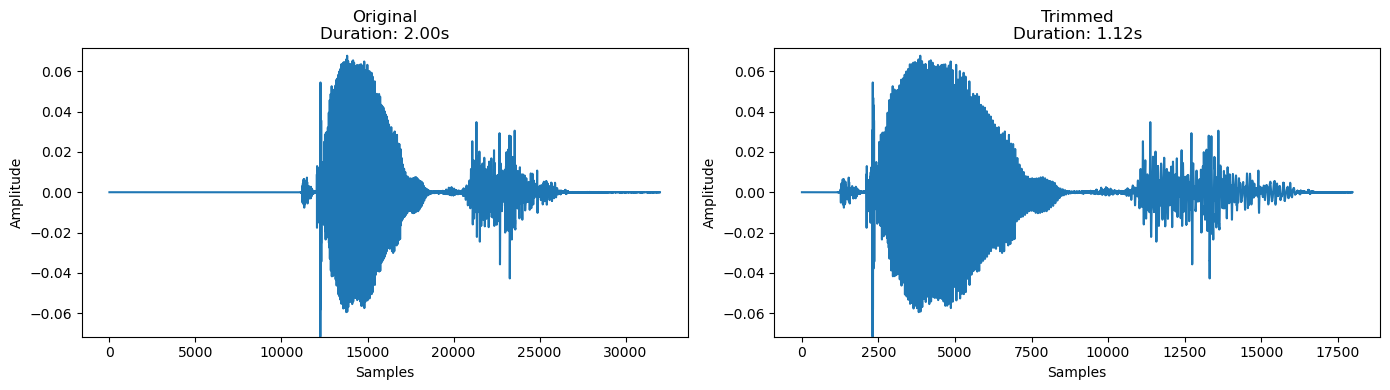

 Original Audio:


 Trimmed Audio:



Class: Alif
File: Alif_haidarshaheen_54a397ad-63a3-4a8d-989f-9ad2f0164182.wav
Child: haidarshaheen

Original:
Sample Rate: 16000 Hz
Duration: 2.000 sec

Trimmed:
Sample Rate: 16000 Hz
Duration: 1.634 sec

Removed Silence: 0.366 sec


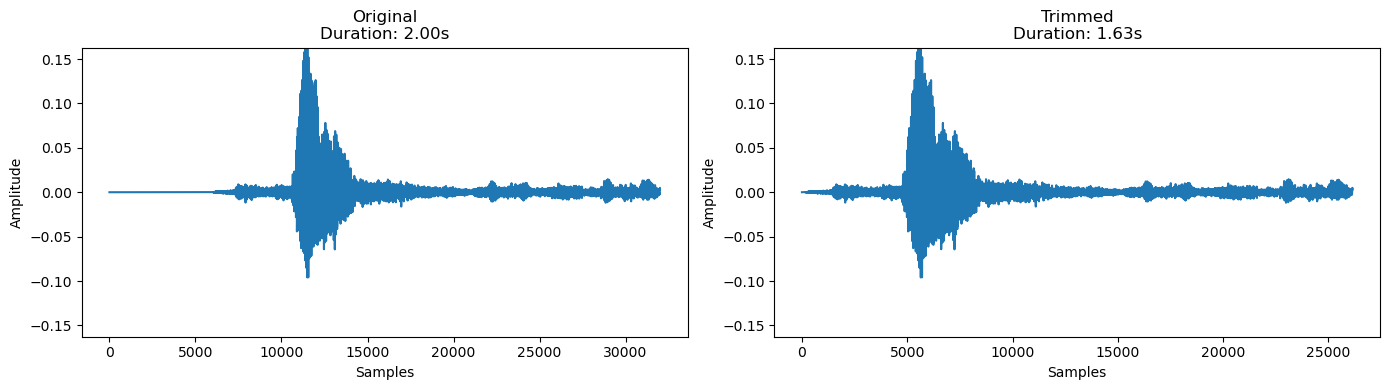

 Original Audio:


 Trimmed Audio:



Class: Tha
File: Tha_bilad_17f58da5-1529-4b7c-8fe8-30d1e396b4cd.wav
Child: bilad

Original:
Sample Rate: 16000 Hz
Duration: 2.000 sec

Trimmed:
Sample Rate: 16000 Hz
Duration: 2.000 sec

Removed Silence: 0.000 sec


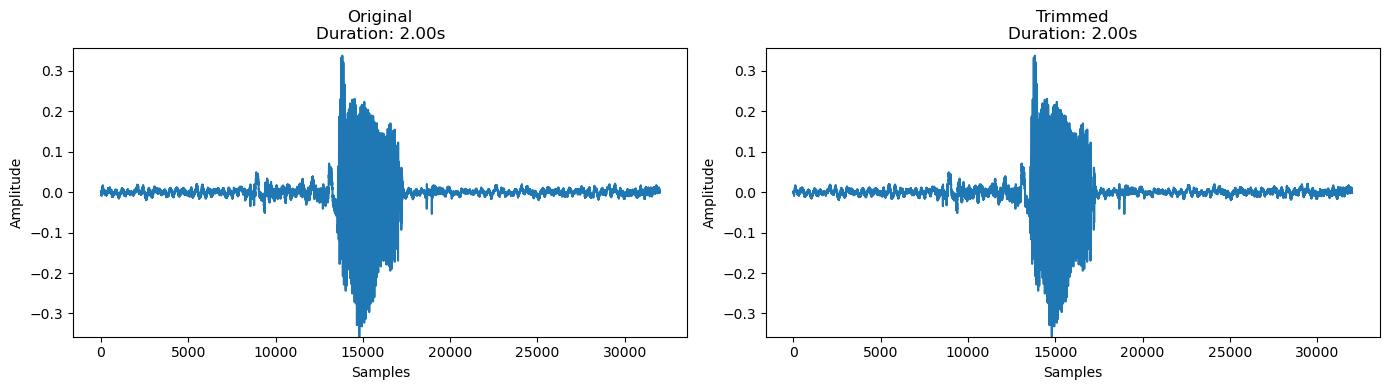

 Original Audio:


 Trimmed Audio:


In [32]:
def compare_original_vs_trimmed(
    df,
    original_path,
    trimmed_path,
    n_samples=5,
    random_state=42
):
    samples = df.sample(n=min(n_samples, len(df)), random_state=random_state)

    for _, row in samples.iterrows():
        class_name = row["class"]
        file_name = row["file_name"]

        original_file = Path(original_path) / class_name / file_name
        trimmed_file = Path(trimmed_path) / class_name / file_name

        if not original_file.exists() or not trimmed_file.exists():
            print(f"Skipping {file_name}: file(s) not found")
            continue

        y_original, sr_original = librosa.load(original_file, sr=None, mono=True)
        y_trimmed, sr_trimmed = librosa.load(trimmed_file, sr=None, mono=True)

        original_duration = len(y_original) / sr_original
        trimmed_duration = len(y_trimmed) / sr_trimmed

        print("\n" + "=" * 70)
        print(f"Class: {class_name}")
        print(f"File: {file_name}")
        if "child_id" in row:
            print(f"Child: {row['child_id']}")

        print("\nOriginal:")
        print(f"Sample Rate: {sr_original} Hz")
        print(f"Duration: {original_duration:.3f} sec")

        print("\nTrimmed:")
        print(f"Sample Rate: {sr_trimmed} Hz")
        print(f"Duration: {trimmed_duration:.3f} sec")

        print(f"\nRemoved Silence: {original_duration - trimmed_duration:.3f} sec")

        # Waveform comparison 
        y_max = max(np.abs(y_original).max(), np.abs(y_trimmed).max())

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].plot(y_original)
        axes[0].set_title(f"Original\nDuration: {original_duration:.2f}s")
        axes[0].set_xlabel("Samples")
        axes[0].set_ylabel("Amplitude")
        axes[0].set_ylim(-y_max, y_max)

        axes[1].plot(y_trimmed)
        axes[1].set_title(f"Trimmed\nDuration: {trimmed_duration:.2f}s")
        axes[1].set_xlabel("Samples")
        axes[1].set_ylabel("Amplitude")
        axes[1].set_ylim(-y_max, y_max)

        plt.tight_layout()
        plt.show()

        print(" Original Audio:")
        display(Audio(y_original, rate=sr_original))

        print(" Trimmed Audio:")
        display(Audio(y_trimmed, rate=sr_trimmed))


# Run comparison
compare_original_vs_trimmed(
    alphabet_data_clean,
    alphabet_path,
    trimmed_path,
    n_samples=3,
    random_state=42
)

In [33]:
# Final Verification of Trimmed Dataset

quality_results = []
missing_files = 0
error_count = 0
total_files = len(alphabet_data_clean)
for i, (_, row) in enumerate(
    alphabet_data_clean.iterrows(), start=1
):
    file_path = (
        Path(trimmed_path)
        / row["class"]
        / row["file_name"]
    )
    if not file_path.exists():
        missing_files += 1
        continue
    try:
        y, sr = librosa.load(
            file_path,
            sr=None,
            mono=True
        )
        duration = len(y) / sr
        max_amplitude = np.max(np.abs(y))
        rms = np.sqrt(np.mean(y ** 2))
        quality_results.append({
            "class": row["class"],
            "file_name": row["file_name"],
            "child_id": row["child_id"],
            "sample_rate": sr,
            "duration": duration,
            "max_amplitude": max_amplitude,
            "rms": rms,
            "is_silent": max_amplitude < 1e-4
        })
    except Exception as e:
        error_count += 1
        print(f"Error processing: {file_path}")
        print(e)
    if i % 1000== 0:
        print(f"Checked {i} / {total_files} files")
# Create final quality DataFrame
final_quality_df = pd.DataFrame(quality_results)
print("========== FINAL DATASET VERIFICATION ==========")
print("Original files:", total_files)
print("Successfully verified:", len(final_quality_df))
print("Missing files:", missing_files)
print("Errors:", error_count)
print("\nClasses:", final_quality_df["class"].nunique())
print("Children:", final_quality_df["child_id"].nunique())
print("\nSample Rate:")
print(final_quality_df["sample_rate"].value_counts())



Checked 1000 / 4676 files
Checked 2000 / 4676 files
Checked 3000 / 4676 files
Checked 4000 / 4676 files
========== FINAL DATASET VERIFICATION ==========
Original files: 4676
Successfully verified: 4676
Missing files: 0
Errors: 0

Classes: 28
Children: 237

Sample Rate:
sample_rate
16000    4676
Name: count, dtype: int64


In [34]:
print("\nDuration Statistics:")
print(final_quality_df["duration"].describe())
print("\nSilent files:", final_quality_df["is_silent"].sum())
# Very short files
very_short = final_quality_df[
    final_quality_df["duration"] < 0.3
]
print("\nFiles shorter than 0.3 sec:", len(very_short))
# Class distribution
print("\nFiles per class:")
print(
    final_quality_df["class"]
    .value_counts()
    .describe()
)


Duration Statistics:
count    4676.00000
mean        1.24333
std         0.59399
min         0.32200
25%         0.67600
50%         1.12400
75%         2.00000
max         2.00000
Name: duration, dtype: float64

Silent files: 0

Files shorter than 0.3 sec: 0

Files per class:
count     28.000000
mean     167.000000
std       11.421228
min      110.000000
25%      167.750000
50%      169.000000
75%      170.000000
max      176.000000
Name: count, dtype: float64


In [35]:
# Class imbalance
print("\nMinimum files in a class:")
print(
    final_quality_df["class"]
    .value_counts()
    .min()
)
print("\nMaximum files in a class:")
print(
    final_quality_df["class"]
    .value_counts()
    .max()
)


Minimum files in a class:
110

Maximum files in a class:
176


    split

In [36]:
def add_split_and_verify(trimmed_df, alphabet_data_clean):

    # Remove old split information if it already exists
    trimmed_df = trimmed_df.drop(
        columns=["child_id", "split"],
        errors="ignore"
    )

    # Get split information for each file
    split_info = (
        alphabet_data_clean[
            ["class", "file_name", "child_id", "split"]
        ]
        .drop_duplicates(["class", "file_name"])
    )

    # Merge split information
    trimmed_df = trimmed_df.merge(
        split_info,
        on=["class", "file_name"],
        how="left",
        validate="one_to_one"
    )

    # Check missing information
    assert trimmed_df["child_id"].notna().all(), \
        "Some files have missing child_id."

    assert trimmed_df["split"].notna().all(), \
        "Some files have missing split."

    # Check data leakage
    leakage = (
        trimmed_df.groupby("child_id")["split"]
        .nunique()
    )

    leakage = leakage[leakage > 1]

    # Print results
    print("========== FINAL SPLIT CHECK ==========")
    print("Total files:", len(trimmed_df))

    print("\nFiles per split:")
    print(trimmed_df["split"].value_counts().sort_index())

    print("\nChildren per split:")
    print(
        trimmed_df.groupby("split")["child_id"]
        .nunique()
        .sort_index()
    )

    print("\nClasses per split:")
    print(
        trimmed_df.groupby("split")["class"]
        .nunique()
        .sort_index()
    )

    print("\nData Leakage:", len(leakage))

    if len(leakage) == 0:
        print(" No data leakage.")
    else:
        print("Data leakage detected!")
        print(leakage)

    return trimmed_df


# Run final split check
trimmed_df = add_split_and_verify(
    trimmed_df,
    alphabet_data_clean
)

========== FINAL SPLIT CHECK ==========
Total files: 4676

Files per split:
split
test      721
train    3485
val       470
Name: count, dtype: int64

Children per split:
split
test      36
train    165
val       36
Name: child_id, dtype: int64

Classes per split:
split
test     28
train    28
val      28
Name: class, dtype: int64

Data Leakage: 0
 No data leakage.


# Target Audio Settings

In [37]:
from pathlib import Path
TARGET_SR = 16000
TARGET_DURATION = 2.0  # the longest one=2s
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

    Padding / Truncation Function

In [38]:
def pad_or_truncate(
    y,
    target_length=TARGET_LENGTH,
    mode="post" #add padding At the end of the file
):
    current_length = len(y)

    # Truncation

    if current_length > target_length:

        y = y[:target_length]


    # Padding

    elif current_length < target_length:

        pad_amount = target_length - current_length

        if mode == "post":

            y = np.pad(
                y,
                (0, pad_amount),
                mode="constant"
            )

        elif mode == "center":

            pad_left = pad_amount // 2
            pad_right = pad_amount - pad_left

            y = np.pad(
                y,
                (pad_left, pad_right),
                mode="constant"
            )

        else:
            raise ValueError(
                "mode must be 'post' or 'center'"
            )

    return y

In [39]:
# Apply Padding / Truncation

def prepare_audio_dataset(
    df,
    audio_path,
    target_sr=TARGET_SR,
    target_length=TARGET_LENGTH,
    mode="post"
):

    audio_arrays = []

    data = []

    errors = 0
    missing_files = 0

    total_files = len(df)

    for i, (_, row) in enumerate(
        df.iterrows(),
        start=1
    ):

        class_name = row["class"]
        file_name = row["file_name"]

        file_path = (
            Path(audio_path)
            / class_name
            / file_name
        )

        # Check file existence

        if not file_path.exists():

            missing_files += 1

            continue

        try:

            # Load trimmed audio

            y, sr = librosa.load(
                file_path,
                sr=target_sr,
                mono=True
            )

            y_fixed = pad_or_truncate(
                y,
                target_length=target_length,
                mode=mode
            )

            audio_arrays.append(
                y_fixed
            )

            data.append({

                "class": row["class"],

                "file_name": row["file_name"],

                "child_id": row["child_id"],

                "split": row["split"]

            })

        except Exception as e:

            errors += 1

            print(
                f"Error processing {file_path}: {e}"
            )

        if i % 1000 == 0:

            print(
                f"Processed {i} / {total_files} files"
            )


    # Convert to NumPy array
    X = np.array(
        audio_arrays,
        dtype=np.float32
    )

    data_df = pd.DataFrame(
        data
    )
    print("\n========== PADDING / TRUNCATION SUMMARY ==========" )

    print("Original files:", total_files)

    print("Successfully processed:", len(X))

    print("Missing files:", missing_files)

    print("Errors:", errors)

    print("X shape:", X.shape)

    print("Expected shape:",(len(X), TARGET_LENGTH))

    print("Sample rate:",target_sr)

    print("Target duration:",target_length / target_sr,"seconds")

    return X, data_df


In [40]:
# Run Padding / Truncation

X, audio_metadata = prepare_audio_dataset(
    df=trimmed_df,
    audio_path=trimmed_path,
    target_sr=TARGET_SR,
    target_length=TARGET_LENGTH,
    mode="post"
)

Processed 1000 / 4676 files
Processed 2000 / 4676 files
Processed 3000 / 4676 files
Processed 4000 / 4676 files

========== PADDING / TRUNCATION SUMMARY ==========
Original files: 4676
Successfully processed: 4676
Missing files: 0
Errors: 0
X shape: (4676, 32000)
Expected shape: (4676, 32000)
Sample rate: 16000
Target duration: 2.0 seconds


    Prepare / Separate the already-defined splits


In [41]:
# Split Data

train_mask = (
    audio_metadata["split"] == "train"
)

val_mask = (
    audio_metadata["split"] == "val"
)

test_mask = (
    audio_metadata["split"] == "test"
)

# Train


X_train = X[train_mask.values]

y_train = audio_metadata.loc[
    train_mask,
    "class"
].values

# Validation

X_val = X[val_mask.values]

y_val = audio_metadata.loc[
    val_mask,
    "class"
].values

# Test

X_test = X[test_mask.values]

y_test = audio_metadata.loc[
    test_mask,
    "class"
].values

print("\n========== FINAL DATA SPLIT ==========")

print(
    "X_train:",
    X_train.shape,
    "| y_train:",
    y_train.shape
)

print(
    "X_val:",
    X_val.shape,
    "| y_val:",
    y_val.shape
)

print(
    "X_test:",
    X_test.shape,
    "| y_test:",
    y_test.shape
)


========== FINAL DATA SPLIT ==========
X_train: (3485, 32000) | y_train: (3485,)
X_val: (470, 32000) | y_val: (470,)
X_test: (721, 32000) | y_test: (721,)


# label encoding

In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(audio_metadata["class"])  

y_train_encoded = le.transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)


In [43]:
print("========== LABEL ENCODING CHECK ==========")

print("Number of classes:", len(le.classes_))

print("Train unique labels:", len(set(y_train_encoded)))
print("Val unique labels:", len(set(y_val_encoded)))
print("Test unique labels:", len(set(y_test_encoded)))

print("\nTrain shape:", y_train_encoded.shape)
print("Val shape:", y_val_encoded.shape)
print("Test shape:", y_test_encoded.shape)

========== LABEL ENCODING CHECK ==========
Number of classes: 28
Train unique labels: 28
Val unique labels: 28
Test unique labels: 28

Train shape: (3485,)
Val shape: (470,)
Test shape: (721,)
